 Import Libraries

In [3]:
import pandas as pd

df = pd.read_csv("../data/customer_shopping_behavior.csv")

df.head()



,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


Load Dataset

In [4]:
df.shape

(3900, 18)

In [5]:
df.columns


Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='str')

Data Overview

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [7]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

Data Cleaning

In [17]:
df["Review Rating"] = df.groupby("Category")["Review Rating"].transform(lambda x: x.fillna(x.median()))

In [18]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

Exploratory Data Analysis (EDA)

1. Total revenue generated from all customer purchases

In [12]:
total_revenue = df["Purchase Amount (USD)"].sum()

print(f"Total Revenue: ${total_revenue:,}")

Total Revenue: $233,081


2.Average purchase amount

In [19]:
average_purchase = df["Purchase Amount (USD)"].mean()

print(f"Average Purchase Amount: ${average_purchase:.2f}")

Average Purchase Amount: $59.76


3. product category generated the most revenue

In [20]:
category_sales = (
    df.groupby("Category")["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64

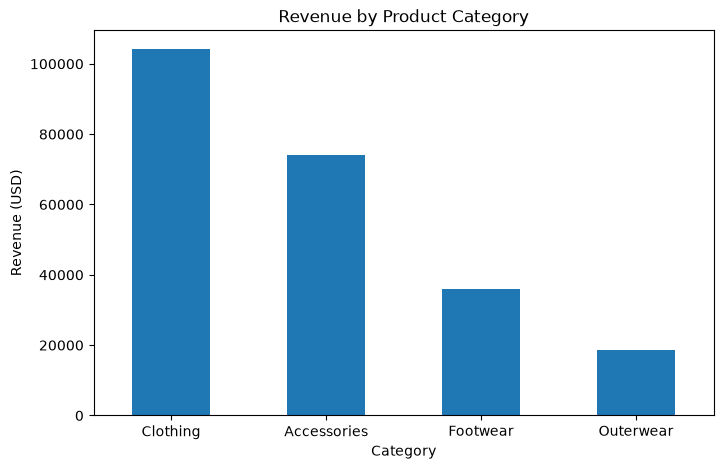

In [21]:
import matplotlib.pyplot as plt

category_sales.plot(kind="bar", figsize=(8,5))

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=0)

plt.show()

Clothing is the highest revenue-generating product category with total sales of $104,264, followed by Accessories ($74,200). Outerwear contributes the least revenue, suggesting it may need promotional strategies or inventory review.

4.Which Gender Spends More

In [22]:
gender_sales = (
    df.groupby("Gender")["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)

print(gender_sales)

Gender
Male      157890
Female     75191
Name: Purchase Amount (USD), dtype: int64


5.Revenue by Season

In [31]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [32]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace(r"[()]", "", regex=True)
)

In [33]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [34]:
season_sales = (
    df.groupby("season")["purchase_amount_usd"]
      .sum()
      .sort_values(ascending=False)
)

print(season_sales)

season
Fall      60018
Spring    58679
Winter    58607
Summer    55777
Name: purchase_amount_usd, dtype: int64


6.Most popular payment method

In [35]:
payment_method = df["payment_method"].value_counts()

print(payment_method)

payment_method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64


7.Top 10 locations by revenue

In [36]:
location_sales = (
    df.groupby("location")["purchase_amount_usd"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(location_sales)

location
Montana          5784
Illinois         5617
California       5605
Idaho            5587
Nevada           5514
Alabama          5261
New York         5257
North Dakota     5220
West Virginia    5174
Nebraska         5172
Name: purchase_amount_usd, dtype: int64


8.Average purchase amount by age

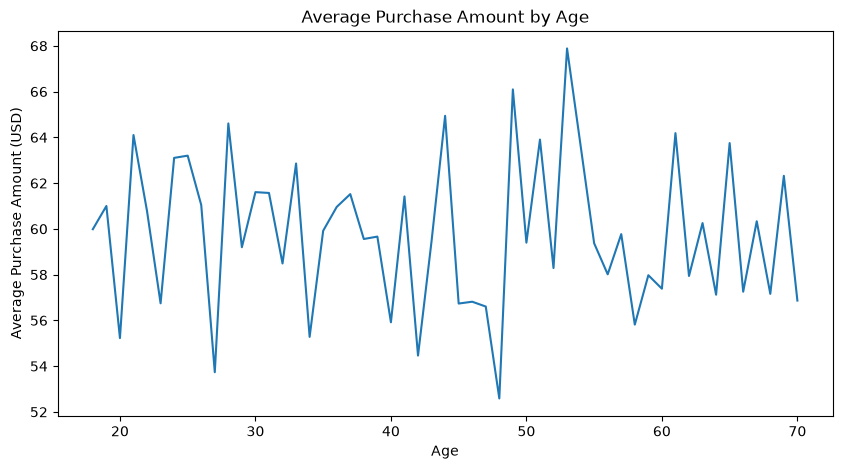

In [37]:
age_purchase = (
    df.groupby("age")["purchase_amount_usd"]
      .mean()
)

plt.figure(figsize=(10,5))
plt.plot(age_purchase.index, age_purchase.values)

plt.title("Average Purchase Amount by Age")
plt.xlabel("Age")
plt.ylabel("Average Purchase Amount (USD)")

plt.show()

gender
Male      157890
Female     75191
Name: purchase_amount_usd, dtype: int64


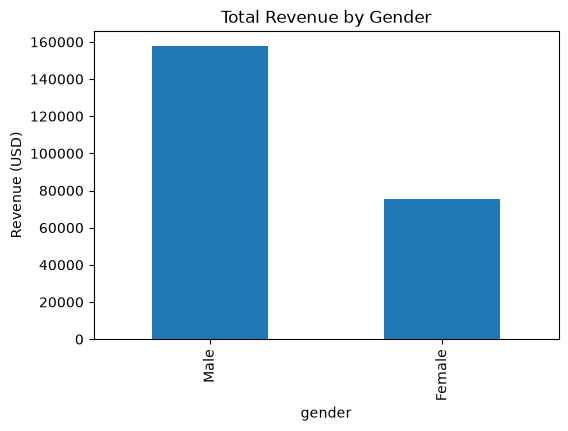

In [38]:
# total revenue generated by male and female customers
gender_revenue = (
    df.groupby("gender")["purchase_amount_usd"]
      .sum()
      .sort_values(ascending=False)
)

print(gender_revenue)

gender_revenue.plot(
    kind="bar",
    figsize=(6,4),
    title="Total Revenue by Gender"
)
plt.ylabel("Revenue (USD)")
plt.show()

In [42]:
#average spending between customers who used discounts and those who didn't.
discount_analysis = (
    df.groupby("discount_applied")["purchase_amount_usd"]
      .agg(["count", "mean", "sum"])
)

print(discount_analysis)

                  count       mean     sum
discount_applied                          
No                 2223  60.130454  133670
Yes                1677  59.279070   99411


item_purchased
Gloves     3.861429
Sandals    3.844375
Boots      3.818750
Hat        3.801299
Skirt      3.785443
Name: review_rating, dtype: float64


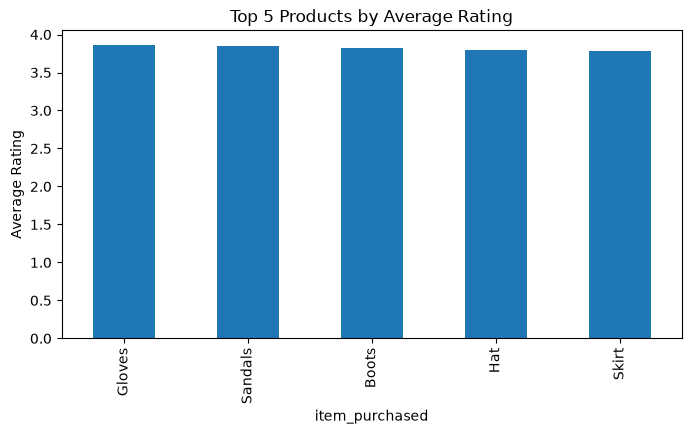

In [40]:
#top 5 products with highest average review rating
top_products = (
    df.groupby("item_purchased")["review_rating"]
      .mean()
      .sort_values(ascending=False)
      .head(5)
)

print(top_products)

top_products.plot(
    kind="bar",
    figsize=(8,4),
    title="Top 5 Products by Average Rating"
)
plt.ylabel("Average Rating")
plt.show()

shipping_type
2-Day Shipping    60.733652
Express           60.475232
Free Shipping     60.410370
Next Day Air      58.631173
Standard          58.460245
Store Pickup      59.893846
Name: purchase_amount_usd, dtype: float64


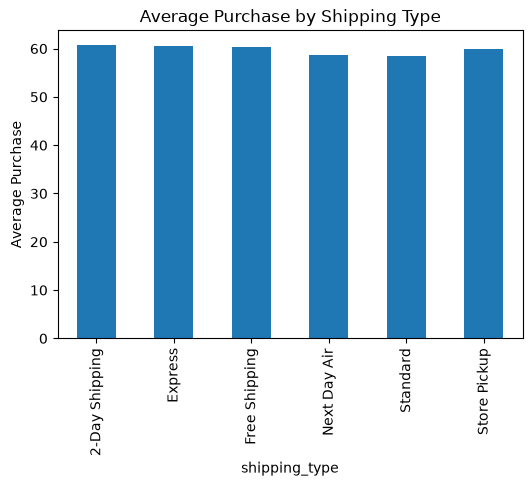

In [41]:
#Compare average purchase amount between Standard and Express Shipping
shipping_avg = (
    df.groupby("shipping_type")["purchase_amount_usd"]
      .mean()
)

print(shipping_avg)

shipping_avg.plot(
    kind="bar",
    figsize=(6,4),
    title="Average Purchase by Shipping Type"
)
plt.ylabel("Average Purchase")
plt.show()

In [44]:
subscription_analysis = (
    df.groupby("subscription_status")["purchase_amount_usd"]
      .agg(
          Average_Spend="mean",
          Total_Revenue="sum",
          Total_Customers="count"
      )
      .round(2)
)

print(subscription_analysis)

                     Average_Spend  Total_Revenue  Total_Customers
subscription_status                                               
No                           59.87         170436             2847
Yes                          59.49          62645             1053


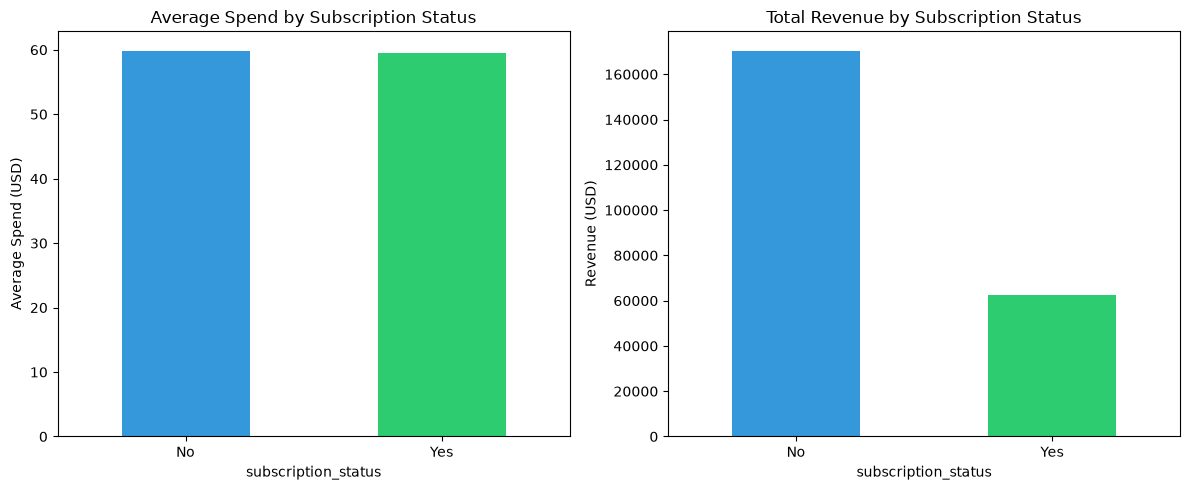

In [ ]:
#average spend and total revenue by subscription status
fig, ax = plt.subplots(1, 2, figsize=(12,5))

subscription_analysis["Average_Spend"].plot(
    kind="bar",
    color=["#3498db", "#2ecc71"],
    ax=ax[0],
    title="Average Spend by Subscription Status"
)
ax[0].set_ylabel("Average Spend (USD)")
ax[0].tick_params(axis="x", rotation=0)

subscription_analysis["Total_Revenue"].plot(
    kind="bar",
    color=["#3498db", "#2ecc71"],
    ax=ax[1],
    title="Total Revenue by Subscription Status"
)
ax[1].set_ylabel("Revenue (USD)")
ax[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

item_purchased
Hat         50.000000
Sneakers    49.655172
Coat        49.068323
Sweater     48.170732
Pants       47.368421
Name: discount_applied, dtype: float64


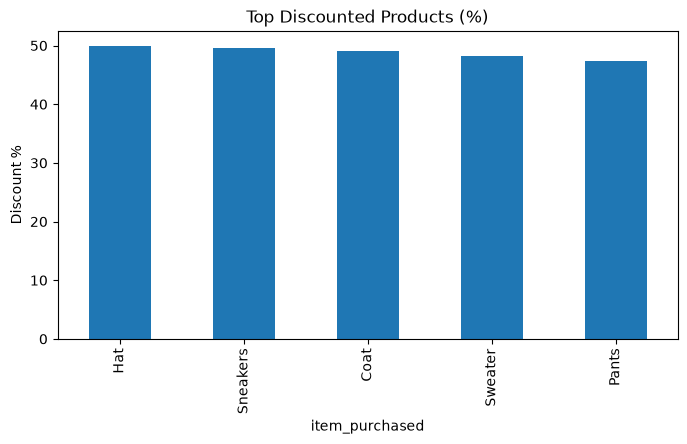

In [47]:
#Five products with the highest percentage of discounted purchases
discount_percent = (
    df.groupby("item_purchased")["discount_applied"]
      .apply(lambda x: (x=="Yes").mean()*100)
      .sort_values(ascending=False)
      .head(5)
)

print(discount_percent)

discount_percent.plot(
    kind="bar",
    figsize=(8,4),
    title="Top Discounted Products (%)"
)
plt.ylabel("Discount %")
plt.show()

In [48]:
#customer segmentation
def segment(x):
    if x == 0:
        return "New"
    elif x <= 5:
        return "Returning"
    else:
        return "Loyal"

df["customer_segment"] = df["previous_purchases"].apply(segment)

segment_summary = (
    df.groupby("customer_segment")["purchase_amount_usd"]
      .agg(["count","mean","sum"])
)

segment_summary

,count,mean,sum
customer_segment,,,
Loyal,3476,59.663119,207389
Returning,424,60.594340,25692


In [49]:
#top 3 purchased products in each category
top_products_category = (
    df.groupby(["category","item_purchased"])
      .size()
      .reset_index(name="purchase_count")
)

top3 = (
    top_products_category
      .sort_values(
          ["category","purchase_count"],
          ascending=[True,False]
      )
      .groupby("category")
      .head(3)
)

top3

,category,item_purchased,purchase_count
5,Accessories,Jewelry,171
1,Accessories,Belt,161
7,Accessories,Sunglasses,161
8,Clothing,Blouse,171
12,Clothing,Pants,171
13,Clothing,Shirt,169
20,Footwear,Sandals,160
21,Footwear,Shoes,150
22,Footwear,Sneakers,145
24,Outerwear,Jacket,163


In [50]:
#are repeated buyers more likely to subscribe?
repeat_buyers = df.copy()

repeat_buyers["repeat_customer"] = (
    repeat_buyers["previous_purchases"] > 5
)

subscription_repeat = pd.crosstab(
    repeat_buyers["repeat_customer"],
    repeat_buyers["subscription_status"],
    normalize="index"
) * 100

subscription_repeat

subscription_status,No,Yes
repeat_customer,,
False,77.594340,22.405660
True,72.439586,27.560414


age_group
18-25    30491
26-35    44342
36-45    43234
46-55    45619
56-65    44352
65+      20904
Name: purchase_amount_usd, dtype: int64


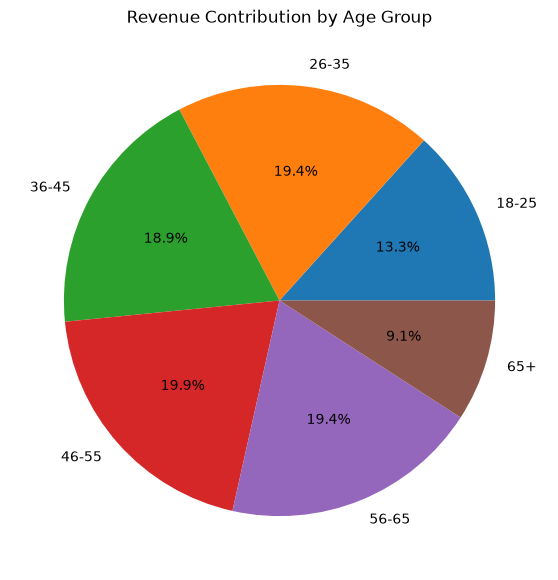

In [51]:
#revenue contribution by age group
bins = [18,25,35,45,55,65,100]
labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "65+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

age_revenue = (
    df.groupby("age_group")["purchase_amount_usd"]
      .sum()
)

print(age_revenue)

age_revenue.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.ylabel("")
plt.title("Revenue Contribution by Age Group")
plt.show()